# **YouTube Analytics Deep Dive of 5000 Channels - Identifying Key Drivers of Channel Growth and Engagement**

## **Index**

1. The Goal of this Project
2. Dataset Overview
3. Data Cleaning
4. EDA (Exploratory Data Analysis)
5. Feature Relationships and Statistical Analysis
6. Key Insights
7. Conclusions and Business Recommendations

## **1] The Goal of this Project**

In today's content creator economy, understanding the factors driving a YouTube channel's growth and audience engagement is critical for content creators, brands and platforms. 

This project analyzes 5000 YouTube Channels to identify the key factors influencing subscriber growth and engagement, and provides data-driven recommendations for optimizing content strategy. 

## **2] Dataset Overview** 

This dataset contains 5,000 YouTube channels with features across technology, paid memberships, and basic platform features, enabling analysis of factors influencing channel growth and audience engagement. 

Below are the details of the columns that the dataset contains - 

1) **Channel Name and YouTuber Name** - These sections discuss who runs the channel, from individual creators to branded studios.
2) **Total videos** - indicates how prolific the channel is.
3) **Best Video** - highlights the most successful or impactful videos
4) **Avg Video Length (min)** - This shows the typical runtime of videos, which helps analyze content pacing and viewer engagement.
5) **Total Subscribers** - This gives a sense of a channel’s reach and influence.
6) **Members Count** - represents paying subscribers, which is a great signal for loyal fanbases.
7) **AI-Generated Content (%)** - reveals how much of the channel's content is powered by artificial intelligence, whether through automated scripts, deep-fakes, or virtual hosts.
8) **Neural Interface Compatible** - tells us if the content is designed to work with next-gen brain-computer interfaces. 
9) **Metaverse Integration Level** - Indicates how involved the channel is with immersive virtual environments. Levels range from no presence to full-blown integration.
10) **Quantum Computing Topics** - counts how many videos cover topics in this complex field, which showcases channels that lean toward high-tech education or discussion.
11) **Holographic Content Rating** - rates how immersive the visual content is, from the basic 1D visuals to 3D holographic presentations.
12) **Engagement Score** - measures how well the audience interacts with the channel, probably combining likes, comments, shares, and view time.
13) **Content Value Index** - gives a summary score of how valuable or meaningful the content is, based on factors like education, originality, and/or entertainment.

#### **Source of the dataset -**
Kaggle Datasets - https://www.kaggle.com/datasets/amansingh0000000/youtube-2025-dataset 

## **3] Data Cleaning**

In [1]:
# Importing all the required packages for conducting EDA
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
# Importing Dataset from Excel
df = pd.read_excel(r"D:\Files On This Laptop (Not Cloud)\xps 16 9640\Documents\Data Analytics Career Requirements\PORTFOLIO ESSENTIALS\archive\YouTube_Channel_Data.xlsx")

In [3]:
df.head()

,Channel Name,Youtuber Name,Total Videos,Best Video,Avg Video Length (min),Total Subscribers,Members Count,AI Generated Content (%),Neural Interface Compatible,Metaverse Integration Level,Quantum Computing Topics,Holographic Content Rating,Engagement Score,Content Value Index
0,Smith-Ross Labs,Eric Patel,68,VR Challenge: Review 2023,24.8,8264152,303319,9,True,Full,5,3D,130655.44,6.2
1,Sandoval PLC Hub,Cynthia Harrington,128,Nanotech Simulation: Analysis 2024,22.9,8768222,384629,62,False,NaN,4,3D,138624.73,21.4
2,"Jones, Moore and Ho Network",Amanda Walker,282,Metaverse Interface: Analysis 2024,24.0,6163386,361743,31,True,Advanced,6,1D,97442.53,13.5
3,Mitchell-Hooper Labs,Jessica Nelson MD,302,VR Protocol: Review 2023,24.6,4712268,58483,5,False,NaN,15,1D,74500.50,12.0
4,Wilson LLC Studios,Matthew Sherman,129,Nanotech Simulation: Review 2024,24.6,9592017,333873,63,True,NaN,12,3D,151648.85,27.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Channel Name                 5000 non-null   object 
 1   Youtuber Name                5000 non-null   object 
 2   Total Videos                 5000 non-null   int64  
 3   Best Video                   5000 non-null   object 
 4   Avg Video Length (min)       5000 non-null   float64
 5   Total Subscribers            5000 non-null   int64  
 6   Members Count                5000 non-null   int64  
 7   AI Generated Content (%)     5000 non-null   int64  
 8   Neural Interface Compatible  5000 non-null   bool   
 9   Metaverse Integration Level  3718 non-null   object 
 10  Quantum Computing Topics     5000 non-null   int64  
 11  Holographic Content Rating   5000 non-null   object 
 12  Engagement Score             5000 non-null   float64
 13  Content Value Inde

**From the above code, it is evident that only the 9th column, that is `Metaverse Integration Level` has some missing entries. The entries could be missing, or it could just mean that `1282 entries` (5000-3718) is not immersive in virtual environments.** 

In [5]:
# Checking the dataset shape 
df.shape

(5000, 14)

In [6]:
# Removing duplicates, if any
df.drop_duplicates().shape

(5000, 14)

**The above codes indicate that there are no duplicates.**

In [7]:
# Checking the sum of the null entries in the dataset
df.isnull().sum()

Channel Name                      0
Youtuber Name                     0
Total Videos                      0
Best Video                        0
Avg Video Length (min)            0
Total Subscribers                 0
Members Count                     0
AI Generated Content (%)          0
Neural Interface Compatible       0
Metaverse Integration Level    1282
Quantum Computing Topics          0
Holographic Content Rating        0
Engagement Score                  0
Content Value Index               0
dtype: int64

In [8]:
Null_Entries = df[df['Metaverse Integration Level'].isnull()]
print(Null_Entries)

                           Channel Name       Youtuber Name  Total Videos  \
1                      Sandoval PLC Hub  Cynthia Harrington           128   
3                  Mitchell-Hooper Labs   Jessica Nelson MD           302   
4                    Wilson LLC Studios     Matthew Sherman           129   
9                 Jackson Group Network         Anne Adkins           140   
10                 Austin-Bowen Studios         David Clark            52   
...                                 ...                 ...           ...   
4975                   Horton-Hunt Labs        Amy Thompson           478   
4985  Snyder, Moody and Dickson Network         Pamela Khan           126   
4987            Johnson-Rosales Network          Donna Lane           417   
4989               Knight and Sons Labs        Patrick Reed           193   
4990                    Cole-Sharp Labs        Erin Bradley           231   

                               Best Video  Avg Video Length (min)  \
1     

**By comparing the dataset on MS Excel and the above code, it is evident that the `Metaverse Integration Level` column has four categories. They are - `Basic`, `Full`, `Advanced` and `None`. The columns that have the entry `None` are the `1282 entries`. This means that they are technically not blanks, but 1282 YouTube channels do not immerse in virtual environments. Hence, we are not removing the blanks but keeping them, as they are useful for our data analysis.** 

## **4] EDA (Exploratory Data Analysis)**

In [9]:
df.describe()

,Total Videos,Avg Video Length (min),Total Subscribers,Members Count,AI Generated Content (%),Quantum Computing Topics,Engagement Score,Content Value Index
count,5000.00000,5000.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,274.43340,24.004540,5.058482e+06,249082.01980,49.328600,10.061400,79974.100470,21.841560
std,131.71675,0.874555,2.890895e+06,143555.47327,29.444246,6.093953,45704.767088,9.863744
min,50.00000,19.100000,1.755000e+03,143.00000,0.000000,0.000000,27.750000,0.000000
25%,159.00000,23.500000,2.547991e+06,127000.75000,24.000000,5.000000,40283.490000,14.200000
50%,274.00000,24.000000,5.105967e+06,252320.50000,49.000000,10.000000,80724.840000,21.800000
75%,389.00000,24.500000,7.541903e+06,371419.25000,76.000000,15.000000,119236.752500,29.700000
max,500.00000,28.900000,9.999975e+06,499991.00000,100.000000,20.000000,158098.630000,44.000000


From the descriptive statistics shown in the YouTube dataset, some observations were made - 

* About 49% of all content is **AI-Generated** and therefore, half of the entire content is human-generated. AI hasn’t entirely taken over yet.  
* The **Engagement Score** ranges widely from about 28 to 158,000, and the mean is about 80,000, which indicates that interaction occurs differently among viewers, depending on the channel.
* The mean of the **Content Value Index** was about 22, with a maximum of 44, which shows there is some amount of variation in the perception of the content.  
* The **Quantum Computing** videos are small, with an average of around 10 per channel. This indicates that this is still a niche subject among content creators. 

What is to be made from all of this is that there is a clear range of variety across channels in participation, content strategy and choice of subject, suggesting that this kind of channel performance is determined from multiple points of influence rather than from a single driving factor.

This sparks consideration of the factors which have the most impact on channel engagement and growth.

**Variability Across Key Features**
1. Higher variability is observed in **Total Subscribers** and **Engagement Score**, reflecting a greater deviation between low-performing and high-performing channels. 
2. **Members Count** is also very heterogeneous and indicates a very obvious divergence in how channels monetize their following.
3. **Average Video Length** and **Quantum Computing Topics**, on the other hand, have comparatively less variance, which suggests a more consistent content format (i.e., specific, niche topic coverage). 

Finally, the dataset appears as a combination of extremely uneven performance metrics accompanied by relatively standard content characteristics.

### **1) Analyzing all Variables and their Visualizations**

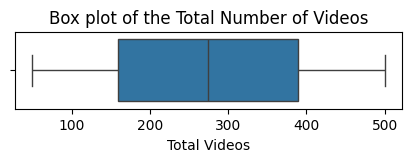

In [10]:
# Creating a boxplot to understand how prolific the YouTube channel is through `Total Videos`
plt.figure(figsize=(5,1))
plt.title("Box plot of the Total Number of Videos")
sns.boxplot(x=df['Total Videos'])
plt.show()

**The total number of YouTube videos uploaded ranges from approximately `160 to almost 400`.** This indicates that, while some content creators may produce content moderately, others are significantly more active in terms of uploading content to their channels. The variation indicates that the content creators have no fixed strategy in terms of the volume of content they produce, and creators differ widely in how frequently they publish content. 

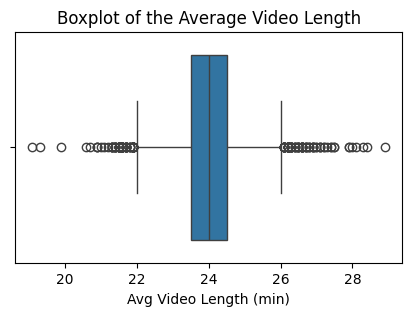

In [11]:
# Creating a Boxplot to understand the distribution of the `Average Video Length`
plt.figure(figsize=(5,3))
plt.title("Boxplot of the Average Video Length")
sns.boxplot(x=df['Avg Video Length (min)'])
plt.show();

**From the above Boxplot, it can be seen that the above variable `Average Video Length (min)` has outliers before 22 and after 26.** Outliers are extreme values. To some extent, most values fall within **`24 minutes`** up and down — not including the outliers. This boxplot shows that content creators follow a standard video duration, while some play with lengths shorter than 22 minutes and longer than 26 minutes. It would make sense to analyze this variable in relation to engagement metrics because these outliers can impact audiences at different rates and with varying results.

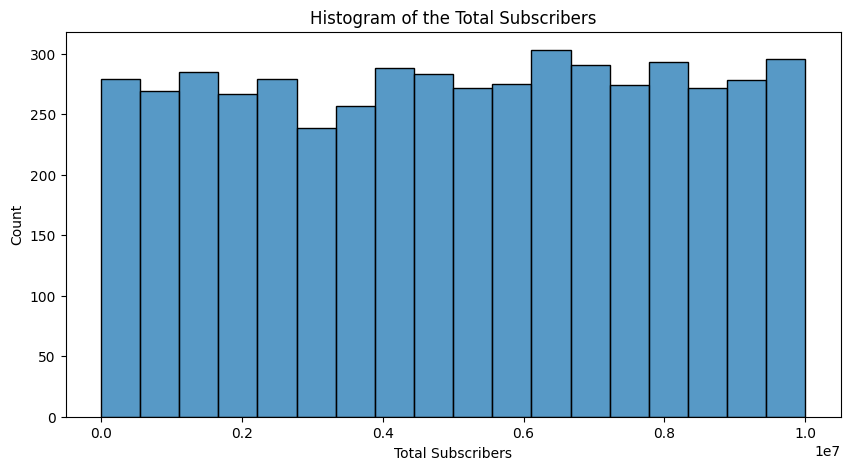

In [12]:
# Creating a Histogram of the `Total Subscribers`
plt.figure(figsize=(10,5))
plt.title("Histogram of the Total Subscribers")
sns.histplot(x=df['Total Subscribers'])
plt.show();

**The above Histogram suggest that the followers for YouTube channels range from `near 0 to 10 Million subscribers`, indicating a wide spread across channels.** It is quite interesting to note that the distribution appears relatively even across the range, indicating that the subscribers are evenly distributed across different channels rather than being heavily concentrated in a specific range. This portrays a balanced dataset with a mix of small, medium and large channels, highlighting significant differences in audience reach. 

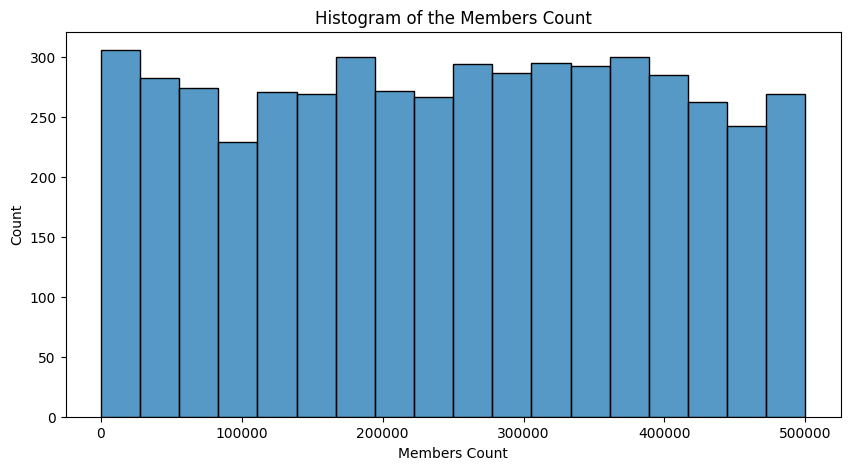

In [13]:
# Creating a Histogram of the `Members Count`
plt.figure(figsize=(10,5))
plt.title("Histogram of the Members Count")
sns.histplot(x=df['Members Count'])
plt.show();

This Histogram shows that **`"Members Count"` is relatively evenly distributed across most bins**, indicating that paid memberships are not concentrated in a specific group of channels. This means that paid members are spread across different channel sizes and are not restricted to just the popular content creators. The slight dip around the 100,000 mark appears to be minor and does not significantly impact the overall uniform distribution. 

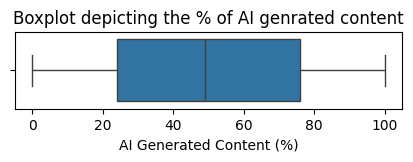

In [14]:
# Creating a Boxplot to find out the distribution of AI-generated content (%)
plt.figure(figsize=(5,1))
plt.title("Boxplot depicting the % of AI genrated content")
sns.boxplot(x=df['AI Generated Content (%)'])
plt.show();

**The above boxplot shows that the percentage of AI-generated content varies significantly across channels, with most of the values falling between approximately `22% to 78%`.** This means that the usage of AI is not consistent. While some of the creators may heavily rely on AI, some may use it sparingly or not at all. This suggests that AI adoption is not standardized among content creators. 

In [15]:
df['Neural Interface Compatible'].value_counts()

Neural Interface Compatible
True     2529
False    2471
Name: count, dtype: int64

**The output of the above code shows that `50.58%` of YouTube channels are neural interface compatible, while `49.42%` are not.** This almost-even split in the usage suggests that neural compatibility is neither widely used nor is it a rarity among creators. Instead, this indicates that this technology is still in a transitional phase, with adoption levels varying across channels. 

In [16]:
df['Metaverse Integration Level'].value_counts()

Metaverse Integration Level
Full        1248
Basic       1236
Advanced    1234
Name: count, dtype: int64

**The distribution of metaverse integration levels is fairly balanced across categories, with channels almost evenly split between basic, advanced, full integration and no integration**. This indicates that there is no dominant level of metaverse adoption among YouTube channels. What this means is that creators are experimenting at different stages of metaverse integration, and that this technology is still evolving. 

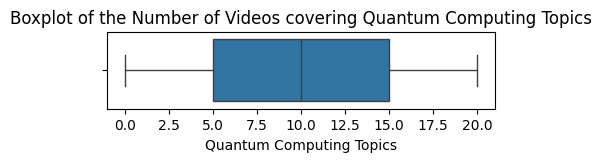

In [17]:
# Boxplot of YouTube Videos that cover Quantum Computing topics
plt.figure(figsize=(5,1))
plt.title("Boxplot of the Number of Videos covering Quantum Computing Topics")
sns.boxplot(x=df['Quantum Computing Topics'])
plt.show();

**From the above boxplot, it is evident that only `5 to 15` videos are on Quantum Computing, with an average of around 10 videos.** This suggests that the topic is niche with limited content production in this area compared to more mainstream topics. 

In [18]:
df['Holographic Content Rating'].value_counts()

Holographic Content Rating
2D    1283
3D    1282
1D    1230
4D    1205
Name: count, dtype: int64

**The distribution of `Holographic Content Rating` is fairly even across the four levels (1D, 2D, 3D and 4D).** This means that there is no single level of visual immersion that dominates across channels. There is no standardized approach to the production of visually immersive content. 

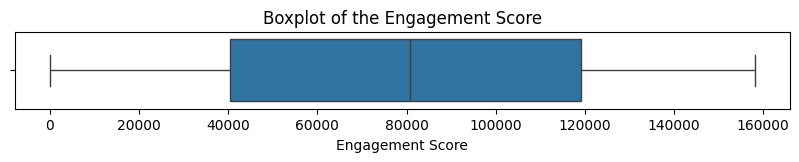

In [19]:
# Boxplot of Engagement Score
plt.figure(figsize=(10,1))
plt.title("Boxplot of the Engagement Score")
sns.boxplot(x=df['Engagement Score'])
plt.show();

**The engagement score ranges between `40,000 to 120,000` with an average score of `80,000`, indicating a moderate central tendency.** A high standard deviation demonstrates significant differences across engagement levels. This indicates that some channels achieve a higher level of traction and viewer involvement, while others experience a lower level of engagement. This highlights an uneven distribution of performance. 

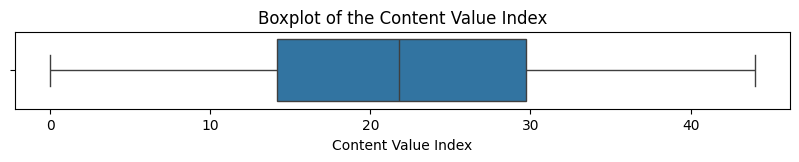

In [20]:
# Boxplot of Content Value Index
plt.figure(figsize=(10,1))
plt.title("Boxplot of the Content Value Index")
sns.boxplot(x=df['Content Value Index'])
plt.show();

**The Content Value Index ranges between `15 to 30` with an average of `22`.** indicating a moderate level of content quality across most channels. The content is generally consistent in terms of quality, without any extreme level of variation. Most of the creators' content is reasonable in terms of originality, education and/or entertainment.  

### **2) Dealing with Outliers**

From the above variable analysis, it is quite evident that out of all the variables, only the `Average Video Length` showed outliers. We shall re-visualize that variable and handle the outliers appropriately. 

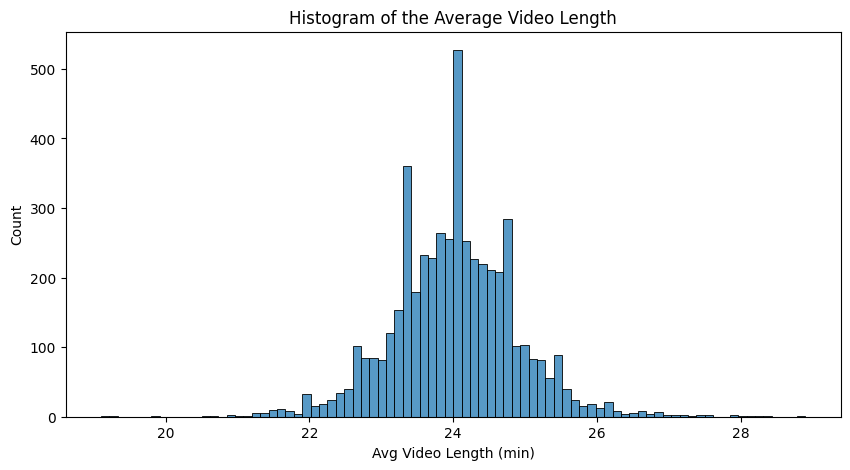

In [21]:
# Visualizing the above column using a Histogram 
plt.figure(figsize=(10,5))
plt.title("Histogram of the Average Video Length")
sns.histplot(x=df['Avg Video Length (min)'])
plt.show();

In [22]:
# Finding out the Inter-Quartile Range, the upper bound and lower bound of the Average Video Length (min) column, to find the outlier threshold. 
Q1 = df['Avg Video Length (min)'].quantile(0.25)
Q3 = df['Avg Video Length (min)'].quantile(0.75)
IQR = Q3 - Q1 

Lower_Bound = Q1 - 1.5 * IQR
Upper_Bound = Q3 + 1.5 * IQR

# Counting the number of values that exceed the outlier threshold. 
Outlier_Count = df[(df['Avg Video Length (min)'] < Lower_Bound) | 
                    df['Avg Video Length (min)'] > Upper_Bound ].shape[0]
print("The number of outliers in the column 'Avg Video Length (min)' is", Outlier_Count)

The number of outliers in the column 'Avg Video Length (min)' is 0


In [23]:
Outliers_Data = df[(df['Avg Video Length (min)'] < Lower_Bound) | 
                    df['Avg Video Length (min)'] > Upper_Bound ] 
print(Outliers_Data)

Empty DataFrame
Columns: [Channel Name, Youtuber Name, Total Videos, Best Video, Avg Video Length (min), Total Subscribers, Members Count, AI Generated Content (%), Neural Interface Compatible, Metaverse Integration Level, Quantum Computing Topics, Holographic Content Rating, Engagement Score, Content Value Index]
Index: []


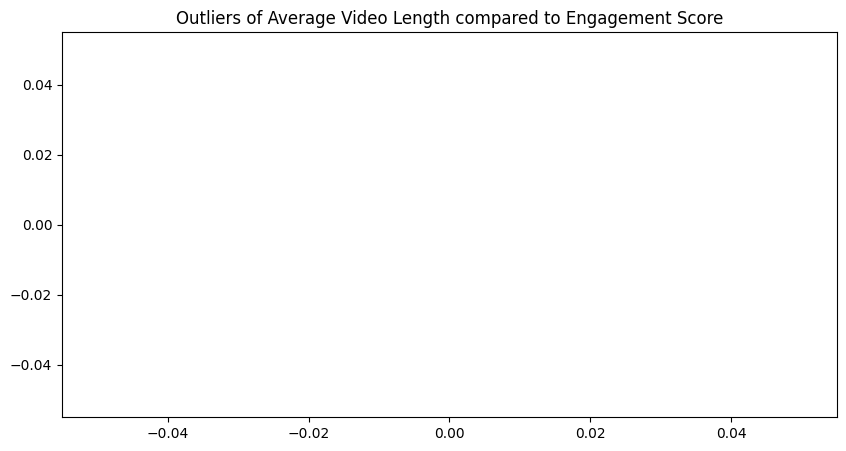

In [24]:
# Visualizing the outliers
plt.figure(figsize=(10,5))
sns.histplot(x=Outliers_Data['Avg Video Length (min)'],
             y=Outliers_Data['Engagement Score'])
plt.title("Outliers of Average Video Length compared to Engagement Score")
plt.show();

**From the above IQR method (usage of `Q1 - 1.5 * IQR`, `Q3 + 1.5 * IQR`), the outliers that we found visually in the boxplot have proven to be completely inbound statistically. This suggests that the previously observed outliers are not statistically far enough to be considered true outliers.** 

**Therefore, no outlier treatment is required for this variable.**

## **5] Feature Relationships and Statistical Analysis**

The goal of this section of the Project is to focus on two things - 
1. Understanding how variables are interdependent. In other words, examining how changes in one feature are associated with changes in others. 
2. Identifying and quantifying the key factors that influence the engagement scores across YouTube channels, to determine which variables play a significant role in driving channel engagement.    

### **1) Correlation Analysis**

To explore how changes in one feature are associated with changes in others, Karl Pearson's correlation analysis has been implemented. Spearman's Rank Correlation or similar methods can capture non-linear monotonic relationships.

**Note -** That the categorical variables - Neural Interface Compatible, Metaverse Integration Level and Holographic Content Rating, were not included in the correlation analysis to avoid the creation of an artificial numerical relationship, but will be included during modelling using relevant encoding techniques.

Text(0.5, 1.0, 'Heatmap of Correlation of the Key Variables')

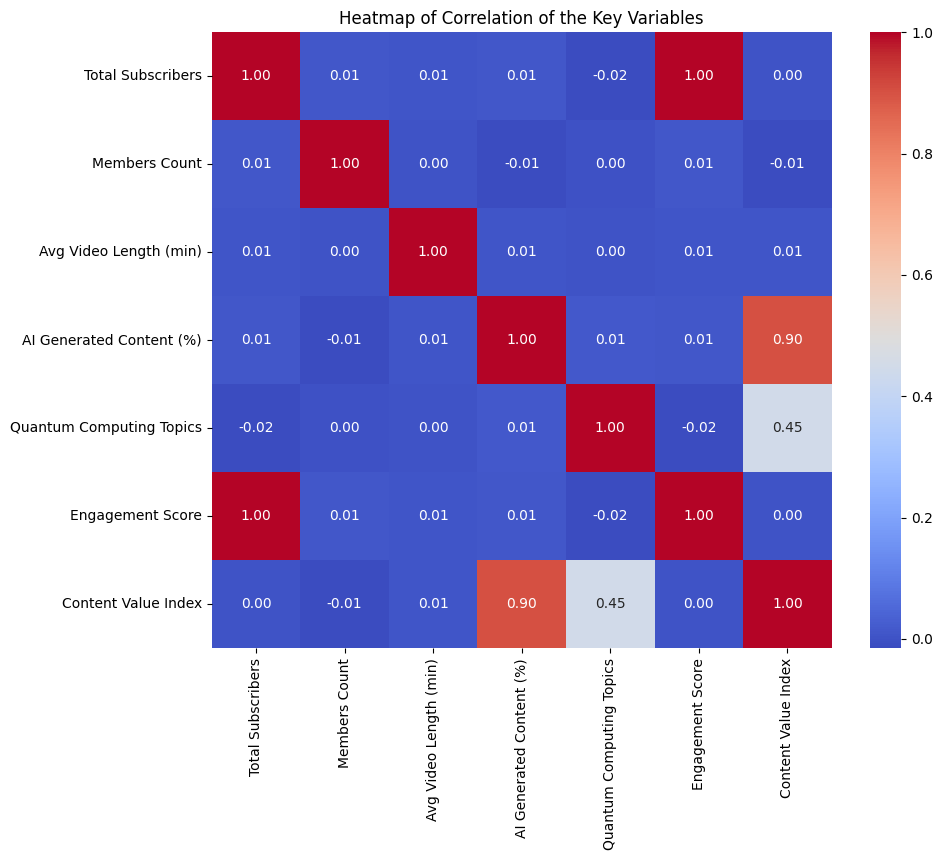

In [25]:
numerical_cols = ['Total Subscribers', 
                  'Members Count',
                  'Avg Video Length (min)',
                  'AI Generated Content (%)', 
                  'Quantum Computing Topics', 
                  'Engagement Score', 
                  'Content Value Index'
                 ]

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title("Heatmap of Correlation of the Key Variables")

#### **Interpretation -**

1. The first thing that is observed is that the Engagement Score shows a perfect positive correlation (1.00) with Total Subscribers. This indicates that the Engagement Score is heavily dependent on Subscriber Count and is likely derived from it. This could be problematic if the viewer engagement were to be treated as an independent variable. However, since the viewer engagement is the target variable in the subsequent analysis, this dependency is expected. This means that there may be high chances for the audience size to dominate model outcomes.

2. AI-generated content shows a strong positive correlation of 0.90 with Content Value Index, which suggests that higher AI usage may be associated with improved content quality.

3. A moderately positive relationship has been observed between Quantum Computing Topics and Content Value Index (0.45). This indicates that niche or specialized content may contribute to a higher perceived value of content.

Overall, the results indicate that while certain features are interrelated, engagement size appears to be largely driven by the size of the audience rather than other individual content characteristics. 

### **2) Regression Analysis**

To determine the variables that play a significant role in driving channel engagement, we will use a **`Multiple Linear Regression Analysis Model`** because we have only one target variable, `Engagement Score` while we have multiple independent variables (more than one). From the correlation Analysis, we observed that Subscriber Count is strongly correlated to Engagement Score. 

Hence, in this section of the project, we will build two regression models - 
1. One including Subscriber Count 
2. Another excluding Subscriber Count

The second model is built to avoid the dominance of scale effects caused by audience size in the model. This allows us to better understand the influence of other variables on engagement. 

### **1] Multiple Linear Regression Analysis Model including the independent variable `Subscriber Count`**

Before we go ahead and define the independent variables (X) and the dependent (target) variable (Y), it is important to convert the three categorical variables - `Neural Interface Compatible`, `Metaverse Integration Level` and `Holographic Content Rating` into numerical values because regressions do not accept anything except numbers. Hence we shall encode each of the three variables. 

#### **a) Encoding the variable `Neural Interface Compatible`**

The variable was encoded into a `binary format (0 and 1)`, where `True is mapped to 1` and `False to 0`.

In [26]:
# This is to figure out the data type of the values in the Neural Interface Compatible Column
df['Neural Interface Compatible'].unique()

array([ True, False])

In [27]:
# encoding the variable Neural Interface Compatible 
df['Neural Interface Compatible'] = df['Neural Interface Compatible'].astype(int)

In [28]:
df['Neural Interface Compatible'].value_counts()

Neural Interface Compatible
1    2529
0    2471
Name: count, dtype: int64

**In the above code, `True` is `1` and `False` is `0`.**

#### **b) Encoding the variable `Metaverse Integration Level`**

There are 3 categories under this column - Basic, Advanced and Full. **There are `1282` null values (NaN), which actually means that metaverse integration is absent. This is important information, and hence it will be meaningful to convert all the null values into a new category `No Integration`** so that the regression does not break. So, before we encode this variable using `Label encoding`, we will convert the nulls to the new category.  

In [29]:
# Converting NaNs to a new category `No Integration`
df['Metaverse Integration Level'] = df['Metaverse Integration Level'].fillna('No Integration')

In [30]:
df['Metaverse Integration Level'].value_counts()

Metaverse Integration Level
No Integration    1282
Full              1248
Basic             1236
Advanced          1234
Name: count, dtype: int64

In [31]:
# Ensuring clean strings to reduce error
df['Metaverse Integration Level'] = df['Metaverse Integration Level'].str.strip()

In [32]:
# label encoding Metaverse Integration Level
df['Metaverse Integration Level'] = df['Metaverse Integration Level'].map({'No Integration':0,
                                                                           'Basic':1,
                                                                           'Advanced':2,
                                                                           'Full':3})

In [33]:
df['Metaverse Integration Level'].value_counts()

Metaverse Integration Level
0    1282
3    1248
1    1236
2    1234
Name: count, dtype: int64

#### **c) Encoding the variable `Holographic Content Rating`**

There are 4 categories of content - 1D, 2D, 3D and 4D. Though it may look like 4D > 3D > 2D > 1D, we cannot actually say that 4D is mathematically 4 times that of 1D or 2 times 2D is 4D, for instance. Such statements can be rendered incorrect. Hence, instead of label encoding, for this variable, we shall go ahead with `One-Hot Encoding`.  

In [34]:
# Using drop_first = True to avoid dummy variable trap
df = pd.get_dummies(df, columns=['Holographic Content Rating'], drop_first=True)

In [35]:
df.columns

Index(['Channel Name', 'Youtuber Name', 'Total Videos', 'Best Video',
       'Avg Video Length (min)', 'Total Subscribers', 'Members Count',
       'AI Generated Content (%)', 'Neural Interface Compatible',
       'Metaverse Integration Level', 'Quantum Computing Topics',
       'Engagement Score', 'Content Value Index',
       'Holographic Content Rating_2D', 'Holographic Content Rating_3D',
       'Holographic Content Rating_4D'],
      dtype='object')

#### **d) The Modelling**

In [36]:
df.drop(['Channel Name', 'Youtuber Name', 'Best Video'], axis=1, inplace=True)

In [37]:
df.columns

Index(['Total Videos', 'Avg Video Length (min)', 'Total Subscribers',
       'Members Count', 'AI Generated Content (%)',
       'Neural Interface Compatible', 'Metaverse Integration Level',
       'Quantum Computing Topics', 'Engagement Score', 'Content Value Index',
       'Holographic Content Rating_2D', 'Holographic Content Rating_3D',
       'Holographic Content Rating_4D'],
      dtype='object')

In [38]:
# Defining Target Variable (Y) and independent variable (X)
Y = df['Engagement Score']
X = df.drop(['Engagement Score'], axis=1)

In [39]:
Y.shape

(5000,)

In [40]:
X.shape

(5000, 12)

In [41]:
X.dtypes

Total Videos                       int64
Avg Video Length (min)           float64
Total Subscribers                  int64
Members Count                      int64
AI Generated Content (%)           int64
Neural Interface Compatible        int64
Metaverse Integration Level        int64
Quantum Computing Topics           int64
Content Value Index              float64
Holographic Content Rating_2D       bool
Holographic Content Rating_3D       bool
Holographic Content Rating_4D       bool
dtype: object

In [42]:
Bool_Cols = X.select_dtypes(include='bool').columns
X[Bool_Cols] = X[Bool_Cols].astype(int)

In [43]:
X.dtypes

Total Videos                       int64
Avg Video Length (min)           float64
Total Subscribers                  int64
Members Count                      int64
AI Generated Content (%)           int64
Neural Interface Compatible        int64
Metaverse Integration Level        int64
Quantum Computing Topics           int64
Content Value Index              float64
Holographic Content Rating_2D      int64
Holographic Content Rating_3D      int64
Holographic Content Rating_4D      int64
dtype: object

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
Model = LinearRegression()
Model.fit(X,Y)

LinearRegression()

In [46]:
print("Intercept", Model.intercept_)
print("Coefficients", Model.coef_)

Intercept 0.0005193641554797068
Coefficients [-1.16656859e-07 -1.63550835e-05  1.58099024e-02 -1.88223939e-11
  7.09195371e-07  1.00335783e-04 -7.54980388e-05 -6.45684451e-07
 -2.39220505e-07 -9.22064399e-05 -1.18377091e-04 -9.23517107e-05]


In [47]:
import statsmodels.api as sm

X = sm.add_constant(X)
Model = sm.OLS(Y,X)
Results = Model.fit()

print(Results.summary())

                            OLS Regression Results                            
Dep. Variable:       Engagement Score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.141e+17
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:37:45   Log-Likelihood:                 22153.
No. Observations:                5000   AIC:                        -4.428e+04
Df Residuals:                    4988   BIC:                        -4.420e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

**Interpretation of the Model with Subscribers -**

The regression model, which includes Subscriber Count as one of the independent variables, shows an R-Squared of 1.00, indicating a perfect fit. But this is rather misleading than desirable because it shows that the Engagement Score is completely explained by only the audience size, which aligns with the earlier correlation findings. This leads to a case of `target leakage` and `severe multicollinearity`. As a result, this model has failed to capture the true drivers of video engagement by rendering other variables statistically insignificant. To address this limitation and better gauge the actual drivers of video engagement, building a second Multiple Linear Regression model, excluding the subscriber count, is crucial to get to the crux of the engagement score. 

### **2] Multiple Linear Regression Analysis Model without `Subscriber Count`**

In [48]:
# Defining independent variables which does not include subscriber count 
X_No_Subs = X.drop(['Total Subscribers'], axis=1)

In [49]:
X_No_Subs.columns

Index(['const', 'Total Videos', 'Avg Video Length (min)', 'Members Count',
       'AI Generated Content (%)', 'Neural Interface Compatible',
       'Metaverse Integration Level', 'Quantum Computing Topics',
       'Content Value Index', 'Holographic Content Rating_2D',
       'Holographic Content Rating_3D', 'Holographic Content Rating_4D'],
      dtype='object')

**Note -** The `const` column that is seen is an intercept (Beta 0) that was added in the previous model when statsmodel was used. We will avoid adding another constant to prevent the creation of duplicate constants.  

In [50]:
Model_No_Subs = sm.OLS(Y, X_No_Subs)
Results_No_Subs = Model_No_Subs.fit()

print(Results_No_Subs.summary())

                            OLS Regression Results                            
Dep. Variable:       Engagement Score   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8941
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.538
Time:                        13:37:45   Log-Likelihood:                -60740.
No. Observations:                5000   AIC:                         1.215e+05
Df Residuals:                    4989   BIC:                         1.216e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

**Interpretation of the Model with `No` Subscribers -**

The `R-Squared` is 0.002, which means that the variables do not explain anything, as `adjusted R-squared` portrays the true value of the model, and in this case, it is 0. Hence, this means that none of the variables explains the viewer engagement. P values that are less than 0.05 are statistically significant, and in this case, all the P > |t| (P values) are greater than 0.05. This means that they are not statistically significant. Only `t` values greater than 2 are statistically significant, and in this case, all the values are less than 2. Hence, again, this proves that the variables are not statistically significant. This means that the model is overall not statistically significant. 

None of the independent variables, including AI-generated content, Holographic Content rating or Content Value Index, are statistically useful driver of engagement. This suggests that none of these variables has a meaningful impact on viewer engagement within this dataset. 

In contrast to the previous model, where audience size dominated viewer engagement, the absence of explanatory power in this model highlights that engagement is overwhelmingly driven by audience size rather than content characteristics.

This reinforces the conclusion that the audience size is the primary driver of engagement in this dataset. 

### **3] Exploring a Multiple Linear Regression Model with `Engagement Rate` instead of Engagement Score as a Target Variable**

A Multiple Linear Regression model where the number of subscribers dominated the viewer engagement score was previously explored, which was misleading due to high multicollinearity. The model was learning that a bigger channel has a higher engagement compared to a smaller channel, and that just does not seem convincing. It just reflects scale and not performance - a scale bias. While a model without a subscriber count rendered cutting-edge technology like AI, metaverse integration, neural interface compatibility and holographic content useless to engagement. 

Hence, to dive deeper into this concern, creating a multiple linear regression model with a new dependent variable - **`Engagement Rate`** may help to discover some statistical relevance. The reasoning behind this is very simple.

let's say that we have two Channels - 

 | Channel | Subscribers | Engagement Score | **Engagement Rate** |
 |---------|-------------|------------------|---------------------|
 | A       | 10,000,000  | 1,000,000        |        0.10         |
 | B       | 10,000      | 50,000           |        5.00         |

**The Engagement Rate can be calculated by dividing the Engagement Score by the Number of Subscribers**. From the above table, the calculated table clearly shows that the engagement rate for a channel with just 10,000 subscribers was significantly higher (5.00) than the engagement rate of 0.10 for a channel of 10 million subscribers. To try to understand if this is the case with the dataset, we will work on a Multiple Linear Regression Model that has Engagement rate as the target variable instead of Engagement Score to eliminate scale bias, as explained earlier and then analyze if scale bias was the issue or if it is something else.   

In [51]:
# Defining the `Engagement Rate`
df['Engagement Rate'] = df['Engagement Score'] / df['Total Subscribers']

In [52]:
# Checking for outliers or division by 0
df = df[df['Total Subscribers'] != 0]

In [53]:
# Defining new target variable Engagement Rate and the independent variables
Y_Rate = df['Engagement Rate'] 
X_Rate = df.drop(['Engagement Score', 'Total Subscribers', 'Engagement Rate'], axis=1)

In [54]:
X_Rate.columns

Index(['Total Videos', 'Avg Video Length (min)', 'Members Count',
       'AI Generated Content (%)', 'Neural Interface Compatible',
       'Metaverse Integration Level', 'Quantum Computing Topics',
       'Content Value Index', 'Holographic Content Rating_2D',
       'Holographic Content Rating_3D', 'Holographic Content Rating_4D'],
      dtype='object')

In [55]:
Y_Rate.shape

(5000,)

In [56]:
X_Rate.shape

(5000, 11)

In [57]:
X_Rate.dtypes

Total Videos                       int64
Avg Video Length (min)           float64
Members Count                      int64
AI Generated Content (%)           int64
Neural Interface Compatible        int64
Metaverse Integration Level        int64
Quantum Computing Topics           int64
Content Value Index              float64
Holographic Content Rating_2D       bool
Holographic Content Rating_3D       bool
Holographic Content Rating_4D       bool
dtype: object

In [58]:
Bool_Rate_Cols = X_Rate.select_dtypes(include='bool').columns
X_Rate[Bool_Rate_Cols] = X_Rate[Bool_Rate_Cols].astype(int)

In [59]:
X_Rate.dtypes

Total Videos                       int64
Avg Video Length (min)           float64
Members Count                      int64
AI Generated Content (%)           int64
Neural Interface Compatible        int64
Metaverse Integration Level        int64
Quantum Computing Topics           int64
Content Value Index              float64
Holographic Content Rating_2D      int64
Holographic Content Rating_3D      int64
Holographic Content Rating_4D      int64
dtype: object

In [60]:
X_Rate = sm.add_constant(X_Rate)
Model_Rate = sm.OLS(Y_Rate,X_Rate)
Results_Rate = Model_Rate.fit()

print(Results_Rate.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement Rate   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.4974
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.893
Time:                        13:37:46   Log-Likelihood:                 78706.
No. Observations:                5000   AIC:                        -1.574e+05
Df Residuals:                    4989   BIC:                        -1.573e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

**Interpretation of the Model with Engagement Rate as the target variable -**

From the above regression model's summary, it is evident that even after removing the scale bias and redefining the target variable as Engagement Rate, the model remains statistically insignificant. 

The Adjusted R-Squared is 0, indicating that the independent variables related to content features, technology, paid memberships, content strategy and basic platform features fail to explain any meaningful variation in the target variable. Furthermore, all the p-values are greater than 0.05, meaning that none of the aforementioned independent variables has a statistically significant relationship with viewer engagement. 

The low t-values across variables further reinforce the model's weak explanatory power of the dataset. 

*Therefore, it can be safely concluded that within the scope of this dataset, the total number of subscribers remains the driving factor influencing overall viewer engagement, while the other variables fail to demonstrate a measurable impact on engagement behaviour.*  

## **6] Key Insights**

**1) Subscriber Count is No. 1 Driver for Engagement -** 
Overall, the subscriber count was found to be the most strongly linked factor for Engagement Score in all regression methods.

**2) Scale Bias in Engagement Metrics is There -** 
The high dependence of the engagement score on subscriber counts reflects a considerable scale bias, whereby larger YouTube channels tend to experience higher engagement values. It makes the raw engagement metrics misleading relative to different channels of different sizes.

**3) Subscriber Count Removing removes predictive power -** 
Excluding the Total Subscribers from the model caused the explanatory power of the model to drop from 1 to 0 (i.e., R-squared ~ 0), and therefore all of the other variables to be statistically insignificant. In other words, here we do not see in absolute terms how the other columns in this dataset explain engagement.

**4) The Engagement Rate Shows No Content-Level Drivers -** 
Despite normalizing engagement (Engagement Rate = Engagement Score / Total Subscribers) to eliminate any scale effect, the regression model also showed little statistical significance. This suggests that —
* Content-related variables.
* Novel technological features such as AI, metaverse integration, neural interface, etc.
* Membership-specific metrics and other platform features.

Do not have significant positive impacts for engagement efficiency in this dataset.

**5) Absence of Strong Predictive Features in the Dataset -** 
The incapability of multiple models to explain viewer engagement indicates that the dataset lacks other crucial variables, such as -
* Content category
* Audience retention rates
* Posting frequency.
* Content title effectiveness.
* Frequency of paid promotions that the channels do.
* Partnerships with others on content.
* Use of clickbait tactics.
  
These are some of the other features that arguably had a greater impact on viewer engagement and channel growth.

**6) Proof of Multicollinearity and Data Limitation –** 
High condition numbers from the summary of all the statistical models demonstrate that multicollinearity exists, which weakens the reliability of the model even further. Nonetheless, the overall lack of significance on the whole refers to restricted feature relevance and not simply technical defects.

## **7] Conclusions and Business Recommendations**

The following recommendations for the Business Management Agency are recommended according to the examination carried out —

**1) Improve Data Collection for more In-Depth Understanding -**
The current findings from the dataset suggest that, beyond a YouTube channel's total subscriber number, there may not be enough factors which explain viewer engagement. In order to increase analytical precision and discover real drivers for viewer engagement, the business should broaden its approach towards data collection. Some additional variables to take into account: Some additional key variables to examine will be –
* Niche content category or category (example - education, finance, entertainment, health and wellness, beauty and lifestyle, technology, gaming, career and corporate talks, etc.)
* Retention rates and average audience watch hours
* How often and consistently creators post.
* Title of content and thumbnail effectiveness (CTR indicators).
* Use of clickbait strategies.
* Frequency of paid offers or sponsored content.
* The frequency with which we collaborate with other creators.
  
The existing dataset gives insight into structural and technological features but lacks behavioural and content-performance measures, which are important for understanding viewer engagement. Thus, the above-mentioned variables have a much stronger correlation to audience behaviour metrics and content performance, and they will probably be utilized as better predictive measures in future models. Nevertheless, the costs may rise, and hence require a more robust data infrastructure to collect and maintain this additional data. However, there is tremendous potential in terms of improving decision-making and content optimization strategies, which could outweigh the costs.

**2) Shift to More Engagement, away from Absolute Engagement -** 
The business should give engagement rate or normalized metrics far more emphasis in measuring creator performance than absolute engagement.
* This allows for a fair comparison among content creators.
* Increases performance benchmarking efficiency.
* There is no bias towards larger YouTube channels.
  
**3) Avoiding Subscriber Count as a Basis for Decision-Making -** 
There is also a danger that business decisions will only be based on the number of subscribers, which means the effectiveness of the content and the overall quality of content won't be assessed by the number of subscribers. This could be due to bias in the data more than effective content.

**4) Bring Performance-Based Creator Evaluation Metrics -** 
The variables in the current dataset were not effective, so the business can develop a stronger creator evaluation framework that includes behaviour metrics like watch time, retention, and audience engagement quality.

**5) Adoption of a Data-Driven Experimentation Approach -** 
In-house data-driven experiments that are incorporated into the dataset should be planned because there are no significant factors to influence engagement in this dataset. This could refer to various content strategies - like video length, the number of posts, and content formats, for example - using controlled experiments like A/B testing. These experiments can be designed and analysed internally or in association with external analytics partners to help the enterprise determine the underlying cause of engagement.